## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid, remove_accents

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
GREEK_TO_EN = str.maketrans({
    "Α": "A", "Β": "V", "Γ": "G", "Δ": "D", "Ε": "E", "Ζ": "Z", "Η": "I", "Θ": "TH",
    "Ι": "I", "Κ": "K", "Λ": "L", "Μ": "M", "Ν": "N", "Ξ": "X", "Ο": "O", "Π": "P",
    "Ρ": "R", "Σ": "S", "Τ": "T", "Υ": "Y", "Φ": "F", "Χ": "CH", "Ψ": "PS", "Ω": "O",
    "α": "a", "β": "v", "γ": "g", "δ": "d", "ε": "e", "ζ": "z", "η": "i", "θ": "th",
    "ι": "i", "κ": "k", "λ": "l", "μ": "m", "ν": "n", "ξ": "x", "ο": "o", "π": "p",
    "ρ": "r", "σ": "s", "ς": "s", "τ": "t", "υ": "y", "φ": "f", "χ": "ch",
    "ψ": "ps", "ω": "o"
})

def greek_to_english(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df[column] = (
        df[column]
        .astype(str)
        .str.translate(GREEK_TO_EN)
    )
    return df

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [5]:
greece_cm_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding=enc)
greece_cm_gdf = greece_cm_gdf.loc[greece_cm_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()

In [6]:
greece_cm_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
9,EL52,EL,Kentriki Makedonia,Κεντρική Μακεδονία,Greece,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [7]:
greece_cm_gdf = greece_cm_gdf.to_crs(epsg=4326)
greece_cm_gdf.drop(columns=['NUTS_NAME'], inplace=True)
greece_cm_gdf.rename(columns={'NUTS_ID': 'div2_code',
                              'CNTR_CODE': 'div0_code',
                              'NAME_LATN': 'div2_name',
                              'CNTR_NAME': 'div0_name'}, inplace=True)

greece_cm_gdf['div1_code'] = 'EL5'
greece_cm_gdf['div1_name'] = 'voreia ellada'
greece_cm_gdf['div0_name'] = 'ellada'
greece_cm_gdf['div2_code'] = 'EL52'

greece_cm_gdf = greece_cm_gdf[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'geometry']].copy()

In [8]:
greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].str.lower()
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].str.lower()
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].str.lower()

greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].apply(lambda x : remove_accents(x))

greece_cm_gdf.reset_index(drop=True, inplace=True)

In [9]:
greece_cm_gdf.head()

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,geometry
0,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


<Axes: >

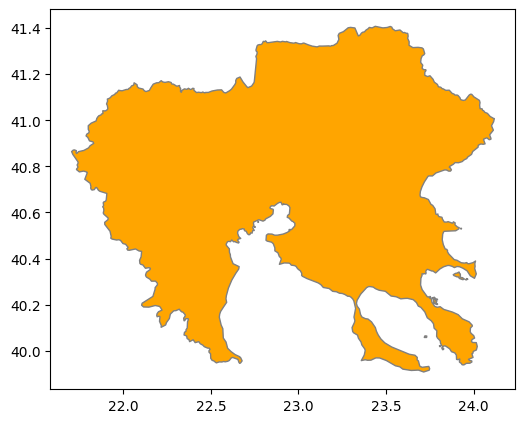

In [10]:
greece_cm_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [11]:
greece_cm_lv3 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS3.shp",  encoding=enc)
greece_cm_lv3 = greece_cm_lv3[greece_cm_lv3['NUTS_ID'].str.startswith(NUTS2_ID, na=False)]
greece_cm_lv3.reset_index(drop=True, inplace=True) 

In [12]:
greece_cm_lv3.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL522,EL,Thessaloniki,Θεσσαλονίκη,2.0,1,1,Greece,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
1,EL523,EL,Kilkis,Κιλκίς,4.0,3,2,Greece,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
2,EL524,EL,Pella,Πέλλα,2.0,3,2,Greece,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
3,EL525,EL,Pieria,Πιερία,4.0,2,1,Greece,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
4,EL526,EL,Serres,Σέρρες,2.0,3,1,Greece,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."


In [13]:
greece_cm_lv3 = greece_cm_lv3.to_crs(epsg=4326)
greece_cm_lv3.drop(columns=['CNTR_CODE', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'CNTR_NAME'], inplace=True)

greece_cm_lv3.rename(columns={'NUTS_ID': 'div3_code',
                              'NAME_LATN': 'div3_name'}, inplace=True)

greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].str.lower()
greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].apply(lambda x : remove_accents(x))

greece_cm_lv3['div0_name'] = 'ellada'
greece_cm_lv3['div0_code'] = 'EL'
greece_cm_lv3['div1_name'] = 'voreia ellada'
greece_cm_lv3['div1_code'] = 'EL5'
greece_cm_lv3['div2_name'] = 'kentriki makedonia'
greece_cm_lv3['div2_code'] = 'EL52'

In [14]:
greece_cm_lv3 = greece_cm_lv3[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'div3_code', 'div3_name',
                               'geometry']].copy()

In [15]:
greece_cm_lv3

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,div3_code,div3_name,geometry
0,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL522,thessaloniki,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
1,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL523,kilkis,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
2,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL524,pella,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
3,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL525,pieria,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
4,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL526,serres,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."
5,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL527,chalkidiki,"MULTIPOLYGON (((23.75687 40.63456, 23.76634 40..."
6,EL,ellada,EL5,voreia ellada,EL52,kentriki makedonia,EL521,imathia,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."


<Axes: >

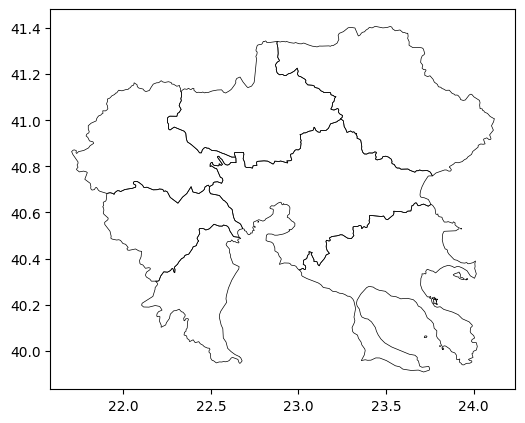

In [16]:
greece_cm_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [17]:
greece_cm_lv4 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding=enc)
process_greek(greece_cm_lv4, 'NAME')
greece_cm_lv4_buffered = greece_cm_lv4.copy()
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:3035") 
greece_cm_lv4_buffered["geometry"] = greece_cm_lv4_buffered.geometry.buffer(-300)

In [18]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered[~greece_cm_lv4_buffered.is_empty & greece_cm_lv4_buffered.is_valid]
greece_cm_lv4.shape == greece_cm_lv4_buffered.shape

True

In [19]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:4326") 
cm = greece_cm_gdf.geometry.iloc[0]
greece_cm_lv4_buffered = greece_cm_lv4_buffered[greece_cm_lv4_buffered.covered_by(cm)]
greece_cm_lv4_buffered.reset_index(drop=True, inplace=True)

<Axes: >

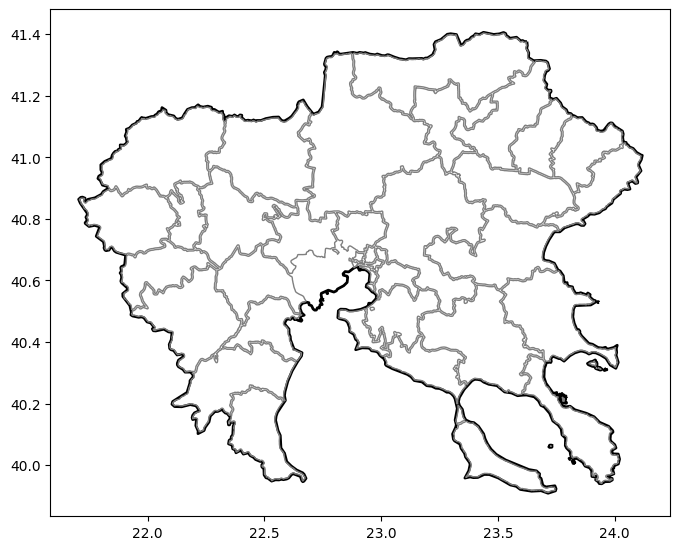

In [20]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4_buffered.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [21]:
kwd_ypes = greece_cm_lv4_buffered.KWD_YPES.to_list()

In [22]:
## This addition is due to missmatching geometries after buffering

## we are manually adding the missing KWD_YPES 9028 Dimos Delta

kwd_ypes.append('9028')

In [23]:
greece_cm_lv4 = greece_cm_lv4[greece_cm_lv4['KWD_YPES'].isin(kwd_ypes)].copy()
greece_cm_lv4.rename(columns={'KWD_YPES': 'div4_code',
                             'NAME': 'div4_name'}, inplace=True)
greece_cm_lv4 = greek_to_english(greece_cm_lv4, "div4_name")
greece_cm_lv4.reset_index(drop=True, inplace=True)

In [24]:
greece_cm_lv4

,div4_name,div4_code,geometry
0,edessas,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
1,alexandreias,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
2,almopias,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
3,ampelokipon menemenis,9026,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
4,amfipolis,9049,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."
5,aristoteli,9056,"MULTIPOLYGON (((23.95413 40.30814, 23.95414 40..."
6,veroias,9024,"POLYGON ((22.27790 40.64388, 22.27864 40.64335..."
7,visaltias,9050,"POLYGON ((23.35679 41.01548, 23.35736 41.01548..."
8,volvis,9027,"POLYGON ((23.49241 40.84242, 23.49332 40.84236..."
9,delta,9028,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."


<Axes: >

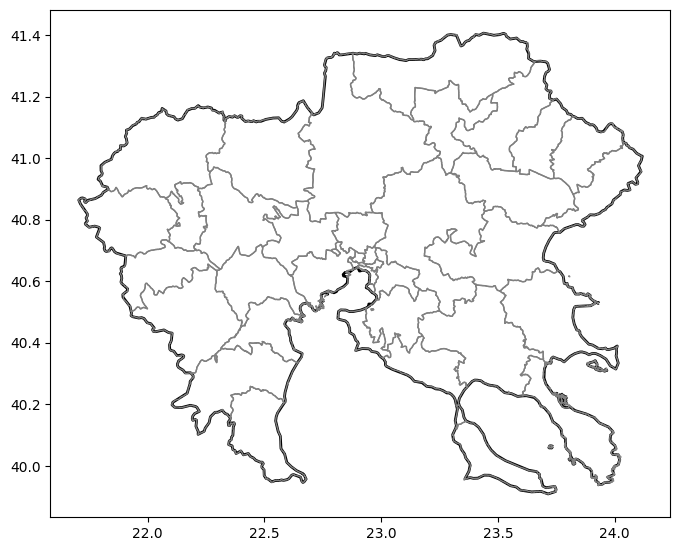

In [25]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [26]:
## GPT Code to enrich lv4 with lv3 attributes

# -------------------------------------------------------------------
# Inputs (already in memory):
#   greece_cm_lv3: polygons with div0..div3 + geometry
#   greece_cm_lv4: polygons with div4 + geometry
# Output:
#   greece_cm_lv4_enriched: lv4 with div0..div3 columns added
# -------------------------------------------------------------------

ADMIN_COLS = [
    "div0_code", "div0_name",
    "div1_code", "div1_name",
    "div2_code", "div2_name",
    "div3_code", "div3_name",
]

# 1) Ensure CRS is set and aligned
if greece_cm_lv3.crs is None or greece_cm_lv4.crs is None:
    raise ValueError(
        "One of the GeoDataFrames has no CRS set. "
        "Set it first with .set_crs(..., inplace=True) before running this."
    )

if greece_cm_lv3.crs != greece_cm_lv4.crs:
    greece_cm_lv4 = greece_cm_lv4.to_crs(greece_cm_lv3.crs)

# 2) Compute inside-points for lv4 (use representative_point to guarantee inside)
lv4 = greece_cm_lv4.copy()
crs_orig = lv4.crs

# For accurate point computations, do it in a metric CRS if current CRS is geographic
if crs_orig.is_geographic:
    # ETRS89 / LAEA Europe (meters) - safe default for Europe/Greece
    lv4_metric = lv4.to_crs(3035)
    lv4_metric["__pt"] = lv4_metric.geometry.representative_point()
    lv4["__pt"] = lv4_metric["__pt"].to_crs(crs_orig)
else:
    lv4["__pt"] = lv4.geometry.representative_point()

lv4_pts = gpd.GeoDataFrame(
    lv4[["div4_code", "div4_name", "__pt"]].copy(),
    geometry="__pt",
    crs=crs_orig,
)

# 3) Spatial join: which lv3 polygon contains the lv4 inside-point?
lv3_for_join = greece_cm_lv3[ADMIN_COLS + ["geometry"]].copy()

# If you suspect invalid geometries in lv3, uncomment:
# lv3_for_join["geometry"] = lv3_for_join.geometry.make_valid()

joined = (
    gpd.sjoin(
        lv4_pts,
        lv3_for_join,
        how="left",
        predicate="within",   # point within polygon
    )
    .drop(columns=["index_right"], errors="ignore")
)

# 4) Merge attributes back onto lv4 polygons
greece_cm_lv4_enriched = (
    greece_cm_lv4
    .merge(joined[["div4_code"] + ADMIN_COLS], on="div4_code", how="left")
)

# 5) Quick diagnostics
missing = greece_cm_lv4_enriched[ADMIN_COLS].isna().any(axis=1)
print(f"Unmatched LV4 rows (no containing LV3 polygon found): {missing.sum()} / {len(missing)}")


Unmatched LV4 rows (no containing LV3 polygon found): 0 / 38


In [27]:
greece_cm_lv4 = greece_cm_lv4_enriched[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [28]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [29]:
df_grid_cm_d2 = create_grid(empty_gdf, greece_cm_gdf, col_municipal='div0_name', dimension=2)

In [30]:
df_grid_cm_d2.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",POINT (21.76333741471462 40.79806323421062),ellada,21.76334,40.79806,2
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",POINT (21.76333741471462 40.816029925810845),ellada,21.76334,40.81603,2
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",POINT (21.76333741471462 40.83399661741106),ellada,21.76334,40.83400,2
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",POINT (21.76333741471462 40.85196330901128),ellada,21.76334,40.85196,2
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",POINT (21.786759980600472 40.79806323421062),ellada,21.78676,40.79806,2


In [31]:
df_grid_cm_d2.shape

(4416, 6)

<Axes: >

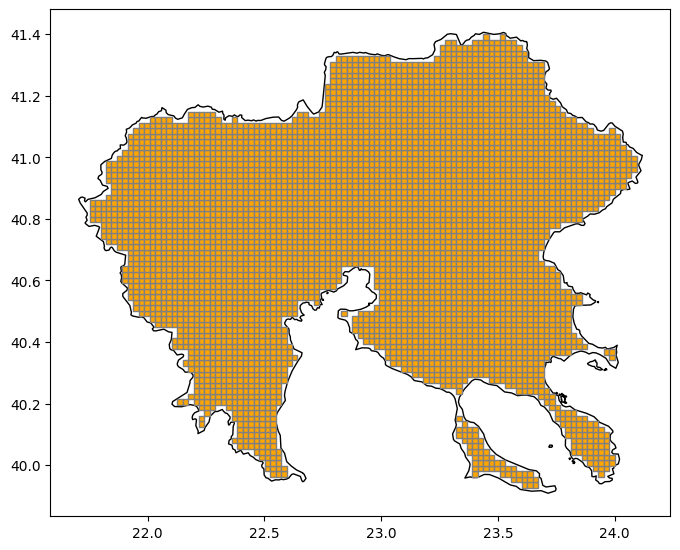

In [32]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_cm_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [33]:
df_grid_cm_d2.set_geometry('centers', inplace=True)
df_grid_cm_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",POINT (21.76334 40.79806),ellada,21.76334,40.79806,2
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",POINT (21.76334 40.81603),ellada,21.76334,40.81603,2
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",POINT (21.76334 40.83400),ellada,21.76334,40.83400,2
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",POINT (21.76334 40.85196),ellada,21.76334,40.85196,2
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",POINT (21.78676 40.79806),ellada,21.78676,40.79806,2
...,...,...,...,...,...,...
4411,"POLYGON ((24.07046 40.98671, 24.07046 41.00468...",POINT (24.05875 40.99570),ellada,24.05875,40.99570,2
4412,"POLYGON ((24.07046 41.00468, 24.07046 41.02265...",POINT (24.05875 41.01366),ellada,24.05875,41.01366,2
4413,"POLYGON ((24.09388 40.95078, 24.09388 40.96875...",POINT (24.08217 40.95976),ellada,24.08217,40.95976,2
4414,"POLYGON ((24.09388 40.96875, 24.09388 40.98671...",POINT (24.08217 40.97773),ellada,24.08217,40.97773,2


In [34]:
greece_cm_grid = gpd.sjoin(df_grid_cm_d2, greece_cm_lv4, how='left', op='within')

In [35]:
greece_cm_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",POINT (21.76334 40.79806),ellada,21.76334,40.79806,2,0,ellada,voreia ellada,kentriki makedonia,pella,edessas,EL,EL5,EL52,EL524,9043
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",POINT (21.76334 40.81603),ellada,21.76334,40.81603,2,0,ellada,voreia ellada,kentriki makedonia,pella,edessas,EL,EL5,EL52,EL524,9043
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",POINT (21.76334 40.83400),ellada,21.76334,40.83400,2,0,ellada,voreia ellada,kentriki makedonia,pella,edessas,EL,EL5,EL52,EL524,9043
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",POINT (21.76334 40.85196),ellada,21.76334,40.85196,2,0,ellada,voreia ellada,kentriki makedonia,pella,edessas,EL,EL5,EL52,EL524,9043
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",POINT (21.78676 40.79806),ellada,21.78676,40.79806,2,0,ellada,voreia ellada,kentriki makedonia,pella,edessas,EL,EL5,EL52,EL524,9043


In [36]:
greece_cm_grid.dropna(inplace=True)

In [37]:
final_grid = greece_cm_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

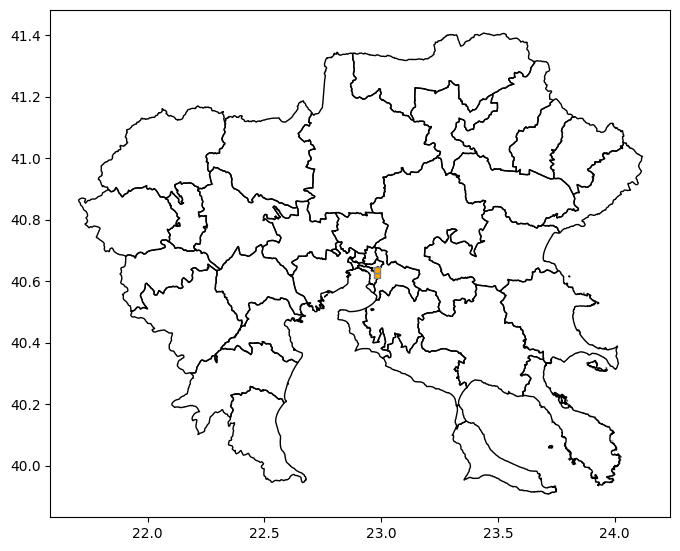

In [38]:
ax = greece_cm_lv4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'thessalonikis'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [39]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (37,)
Shape of cameroon_nord_lv3: (38,)


In [40]:
diff = list(set(greece_cm_lv4.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 1
Missing GIDs are: ['kalamarias']


In [41]:
missing_LAUs_d2 = greece_cm_lv4[greece_cm_lv4.div4_name.isin(diff)].copy()
missing_LAUs_d2.reset_index(drop=True, inplace=True)

In [42]:
missing_LAUs_d2

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry
0,ellada,voreia ellada,kentriki makedonia,thessaloniki,kalamarias,EL,EL5,EL52,EL522,9032,"POLYGON ((22.97084 40.58797, 22.97046 40.58693..."


In [43]:
missing_LAUs_d2["centers"] = missing_LAUs_d2.geometry.centroid

In [44]:
missing_LAUs_d2['resolution_km'] = 1

<Axes: >

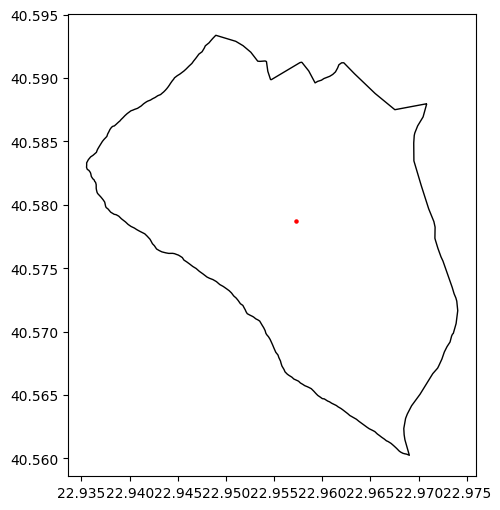

In [45]:
ax = missing_LAUs_d2.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
missing_LAUs_d2['centers'].plot(ax=ax, color='red', markersize=5)

In [46]:
missing_LAUs_d2["x"] = missing_LAUs_d2["centers"].x
missing_LAUs_d2["y"] = missing_LAUs_d2["centers"].y
missing_LAUs_d2 = missing_LAUs_d2[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]



In [47]:
missing_LAUs_d2.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry
0,22.957237,40.578758,ellada,voreia ellada,kentriki makedonia,thessaloniki,kalamarias,EL,EL5,EL52,EL522,9032,1,POINT (22.95724 40.57876),"POLYGON ((22.97084 40.58797, 22.97046 40.58693..."


In [48]:
final_grid = pd.concat([final_grid, missing_LAUs_d2], ignore_index=True)

In [49]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (38,)
Shape of cameroon_nord_lv3: (38,)


In [50]:
final_grid.sort_values(by=['div2_code', 'div3_code', 'div4_code', 'x', 'y'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,22.30206,40.58246,ellada,voreia ellada,kentriki makedonia,imathia,alexandreias,EL,EL5,EL52,EL521,9023,2,"POLYGON ((22.31377 40.57348, 22.31377 40.59145..."
1,22.30206,40.60043,ellada,voreia ellada,kentriki makedonia,imathia,alexandreias,EL,EL5,EL52,EL521,9023,2,"POLYGON ((22.31377 40.59145, 22.31377 40.60941..."
2,22.30206,40.61840,ellada,voreia ellada,kentriki makedonia,imathia,alexandreias,EL,EL5,EL52,EL521,9023,2,"POLYGON ((22.31377 40.60941, 22.31377 40.62738..."
3,22.32548,40.56450,ellada,voreia ellada,kentriki makedonia,imathia,alexandreias,EL,EL5,EL52,EL521,9023,2,"POLYGON ((22.33719 40.55551, 22.33719 40.57348..."
4,22.32548,40.58246,ellada,voreia ellada,kentriki makedonia,imathia,alexandreias,EL,EL5,EL52,EL521,9023,2,"POLYGON ((22.33719 40.57348, 22.33719 40.59145..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4412,23.96506,40.06143,ellada,voreia ellada,kentriki makedonia,chalkidiki,sithonias,EL,EL5,EL52,EL527,9060,2,"POLYGON ((23.97677 40.05245, 23.97677 40.07041..."
4413,23.96506,40.07940,ellada,voreia ellada,kentriki makedonia,chalkidiki,sithonias,EL,EL5,EL52,EL527,9060,2,"POLYGON ((23.97677 40.07041, 23.97677 40.08838..."
4414,23.96506,40.09736,ellada,voreia ellada,kentriki makedonia,chalkidiki,sithonias,EL,EL5,EL52,EL527,9060,2,"POLYGON ((23.97677 40.08838, 23.97677 40.10635..."
4415,23.98848,40.00753,ellada,voreia ellada,kentriki makedonia,chalkidiki,sithonias,EL,EL5,EL52,EL527,9060,2,"POLYGON ((24.00019 39.99855, 24.00019 40.01651..."


In [ ]:
string_cols = final_grid.select_dtypes(include=['object', 'string']).columns

final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.map(remove_accents))
final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.str.replace(r"[,.]", "", regex=True))

In [51]:
if final_grid['div3_code'].isnull().any():
    raise ValueError("div3_code contains NULL values, need rules to handle them.")

# Create a "counter" per div3_code
final_grid['counter'] = final_grid.groupby('div3_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div3_code + hex_counter
final_grid['point_code'] = final_grid['div3_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [52]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

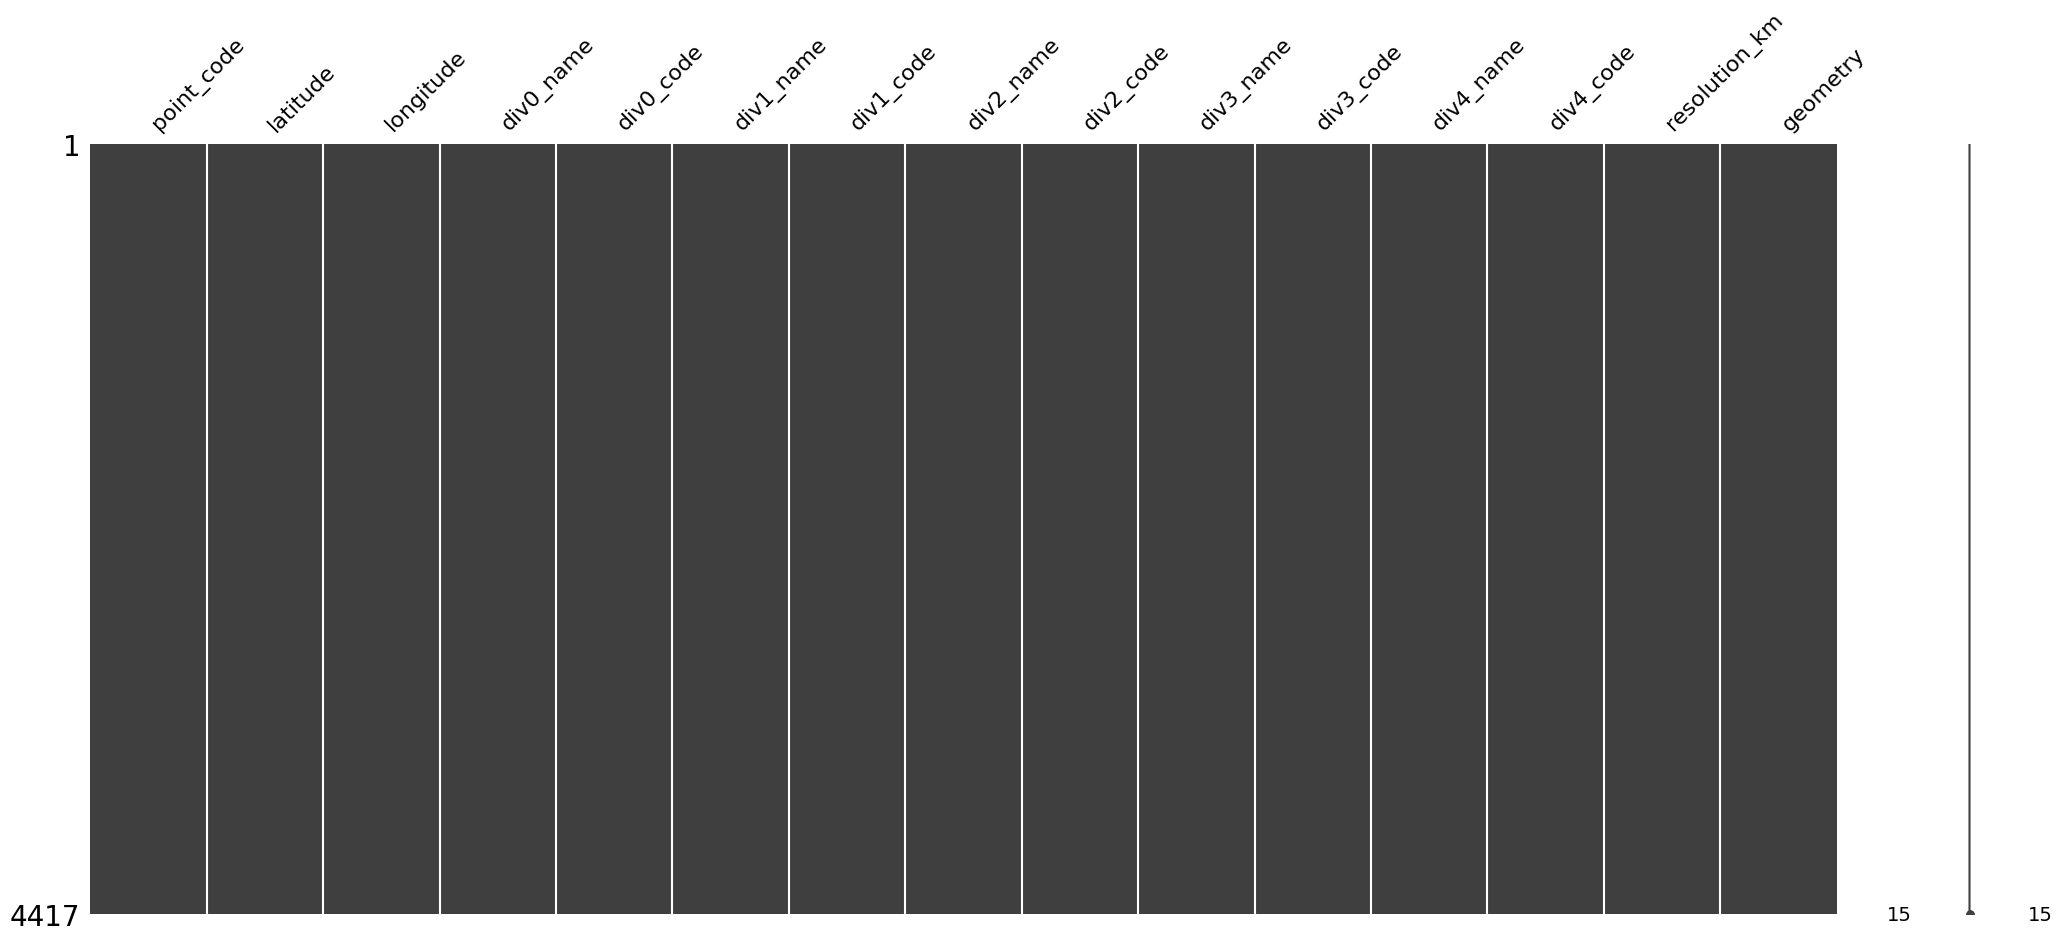

In [53]:
missingno.matrix(final_grid)

In [54]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,EL52100001,40.58246,22.30206,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,imathia,EL521,alexandreias,9023,2,"POLYGON ((22.31377 40.57348, 22.31377 40.59145..."
1,EL52100002,40.60043,22.30206,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,imathia,EL521,alexandreias,9023,2,"POLYGON ((22.31377 40.59145, 22.31377 40.60941..."
2,EL52100003,40.61840,22.30206,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,imathia,EL521,alexandreias,9023,2,"POLYGON ((22.31377 40.60941, 22.31377 40.62738..."
3,EL52100004,40.56450,22.32548,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,imathia,EL521,alexandreias,9023,2,"POLYGON ((22.33719 40.55551, 22.33719 40.57348..."
4,EL52100005,40.58246,22.32548,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,imathia,EL521,alexandreias,9023,2,"POLYGON ((22.33719 40.57348, 22.33719 40.59145..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4412,EL52700268,40.06143,23.96506,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,chalkidiki,EL527,sithonias,9060,2,"POLYGON ((23.97677 40.05245, 23.97677 40.07041..."
4413,EL52700269,40.07940,23.96506,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,chalkidiki,EL527,sithonias,9060,2,"POLYGON ((23.97677 40.07041, 23.97677 40.08838..."
4414,EL5270026A,40.09736,23.96506,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,chalkidiki,EL527,sithonias,9060,2,"POLYGON ((23.97677 40.08838, 23.97677 40.10635..."
4415,EL5270026B,40.00753,23.98848,ellada,EL,voreia ellada,EL5,kentriki makedonia,EL52,chalkidiki,EL527,sithonias,9060,2,"POLYGON ((24.00019 39.99855, 24.00019 40.01651..."


In [56]:
final_grid.drop(columns='geometry').to_csv(f'../../data/CMacedonia/GR_CMacedonia_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')